# Physics-Informed Battery Health Analytics
## NASA B0005 — Exploratory Analysis, SOH Modelling and RUL Prognostics

**Objective:** Build a reproducible battery-health workflow from discharge-cycle data, quantify State of Health (SOH), define End of Life (EOL), and evaluate Remaining Useful Life (RUL) models using chronological validation.

**Important modelling principle:** In battery prognostics, future observations must not leak into model fitting. Accordingly, predictive performance is evaluated with chronological train/test splits rather than random shuffling.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from nasa_loader import load_nasa_battery
from battery_features import add_soh_features, add_degradation_features


## 1. Load and validate NASA battery data


In [2]:
b0005_path = DATA_DIR / "B0005.mat"
b0006_path = DATA_DIR / "B0006.mat"

if not b0005_path.exists():
    raise FileNotFoundError(f"Missing NASA battery file: {b0005_path}")

df_b0005 = load_nasa_battery(b0005_path, "B0005")
df_b0005 = add_soh_features(df_b0005)
df_b0005 = add_degradation_features(df_b0005, window=5)

print("B0005 shape:", df_b0005.shape)
print("Columns:", df_b0005.columns.tolist())
df_b0005.head()


B0005 shape: (168, 17)
Columns: ['record_index', 'discharge_cycle', 'cycle', 'capacity_Ah', 'avg_voltage_V', 'min_voltage_V', 'max_voltage_V', 'avg_current_A', 'avg_temperature_C', 'max_temperature_C', 'discharge_time_s', 'SOH_percent', 'capacity_retention', 'capacity_fade_percent', 'SOH_change_percent', 'SOH_rolling_mean', 'temperature_rolling_mean']


,record_index,discharge_cycle,cycle,capacity_Ah,avg_voltage_V,min_voltage_V,max_voltage_V,avg_current_A,avg_temperature_C,max_temperature_C,discharge_time_s,SOH_percent,capacity_retention,capacity_fade_percent,SOH_change_percent,SOH_rolling_mean,temperature_rolling_mean
0,2,1,1,1.856487,3.529829,2.612467,4.191492,-1.818702,32.572328,38.982181,3690.234,100.000000,1.000000,0.000000,NaN,NaN,NaN
1,4,2,2,1.846327,3.537320,2.587209,4.189773,-1.817560,32.725235,39.033398,3672.344,99.452721,0.994527,0.547279,-0.547279,NaN,NaN
2,6,3,3,1.835349,3.543737,2.651917,4.188187,-1.816487,32.642862,38.818797,3651.641,98.861386,0.988614,1.138614,-0.591335,NaN,NaN
3,8,4,4,1.835263,3.543666,2.592948,4.188461,-1.825589,32.514876,38.762305,3631.563,98.856718,0.988567,1.143282,-0.004668,NaN,NaN
4,10,5,5,1.834646,3.542343,2.547420,4.188299,-1.826114,32.382349,38.665393,3629.172,98.823482,0.988235,1.176518,-0.033236,99.198861,32.56753


In [3]:
required_columns = [
    "cycle",
    "capacity_Ah",
    "avg_voltage_V",
    "min_voltage_V",
    "max_voltage_V",
    "avg_current_A",
    "avg_temperature_C",
    "max_temperature_C",
    "SOH_percent",
]

missing_columns = [c for c in required_columns if c not in df_b0005.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if not df_b0005["cycle"].is_monotonic_increasing:
    df_b0005 = df_b0005.sort_values("cycle").reset_index(drop=True)

print("Missing values in modelling columns:")
print(df_b0005[required_columns].isna().sum())

assert df_b0005["cycle"].is_monotonic_increasing
assert df_b0005["SOH_percent"].notna().all()


Missing values in modelling columns:
cycle                0
capacity_Ah          0
avg_voltage_V        0
min_voltage_V        0
max_voltage_V        0
avg_current_A        0
avg_temperature_C    0
max_temperature_C    0
SOH_percent          0
dtype: int64


## 2. Exploratory degradation analysis


In [4]:
initial_capacity = df_b0005["capacity_Ah"].iloc[0]
final_capacity = df_b0005["capacity_Ah"].iloc[-1]
initial_soh = df_b0005["SOH_percent"].iloc[0]
final_soh = df_b0005["SOH_percent"].iloc[-1]

capacity_loss = initial_capacity - final_capacity
capacity_loss_percent = 100 * capacity_loss / initial_capacity

print(f"Initial capacity: {initial_capacity:.4f} Ah")
print(f"Final capacity:   {final_capacity:.4f} Ah")
print(f"Capacity loss:    {capacity_loss:.4f} Ah ({capacity_loss_percent:.2f}%)")
print(f"Initial SOH:      {initial_soh:.2f}%")
print(f"Final SOH:        {final_soh:.2f}%")


Initial capacity: 1.8565 Ah
Final capacity:   1.3251 Ah
Capacity loss:    0.5314 Ah (28.62%)
Initial SOH:      100.00%
Final SOH:        71.38%


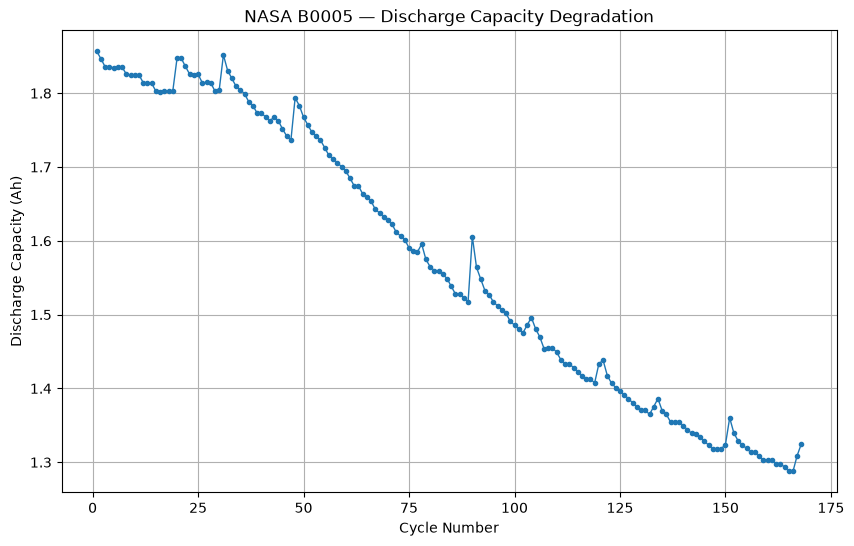

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df_b0005["cycle"], df_b0005["capacity_Ah"], marker="o", markersize=3, linewidth=1)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (Ah)")
plt.title("NASA B0005 — Discharge Capacity Degradation")
plt.grid(True)
plt.show()


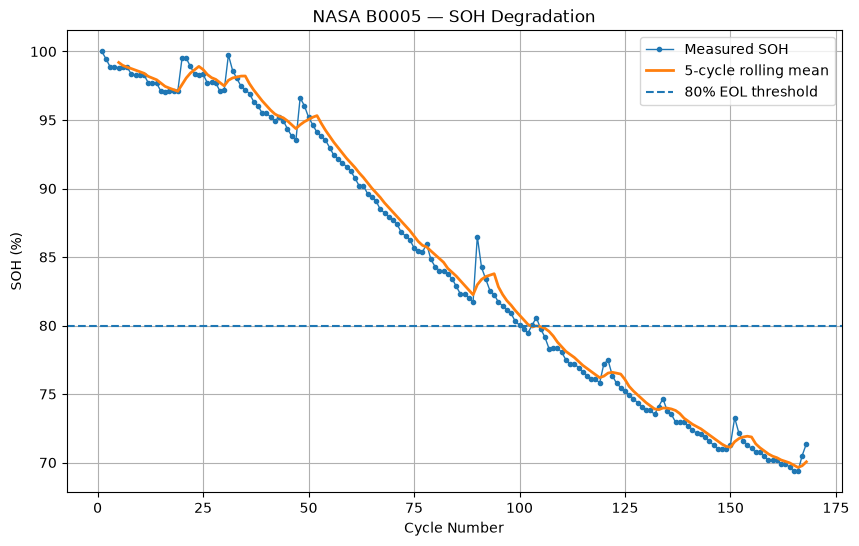

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(
    df_b0005["cycle"],
    df_b0005["SOH_percent"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="Measured SOH",
)

if "SOH_rolling_mean" in df_b0005.columns:
    plt.plot(
        df_b0005["cycle"],
        df_b0005["SOH_rolling_mean"],
        linewidth=2,
        label="5-cycle rolling mean",
    )

plt.axhline(80, linestyle="--", label="80% EOL threshold")
plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.title("NASA B0005 — SOH Degradation")
plt.legend()
plt.grid(True)
plt.show()


## 3. Temperature association with SOH

Correlation is used here as an exploratory diagnostic. Because cycle number and temperature can co-vary during ageing, correlation alone must not be interpreted as evidence that temperature causally explains degradation.


In [7]:
temperature_soh_corr = df_b0005[["avg_temperature_C", "SOH_percent"]].corr().iloc[0, 1]
max_temp_soh_corr = df_b0005[["max_temperature_C", "SOH_percent"]].corr().iloc[0, 1]
cycle_max_temp_corr = df_b0005[["cycle", "max_temperature_C"]].corr().iloc[0, 1]

print(f"Average-temperature–SOH correlation: {temperature_soh_corr:.4f}")
print(f"Maximum-temperature–SOH correlation: {max_temp_soh_corr:.4f}")
print(f"Cycle–maximum-temperature correlation: {cycle_max_temp_corr:.4f}")


Average-temperature–SOH correlation: -0.8097
Maximum-temperature–SOH correlation: -0.9353
Cycle–maximum-temperature correlation: 0.9149


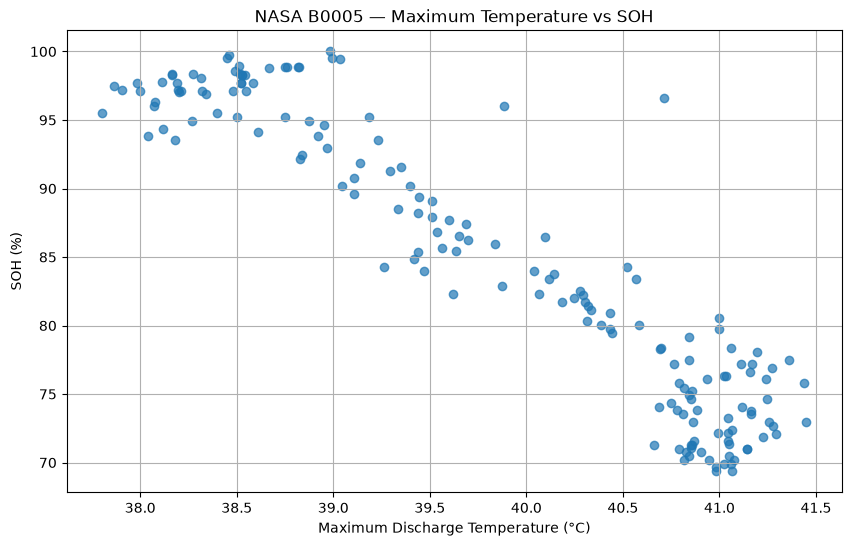

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df_b0005["max_temperature_C"], df_b0005["SOH_percent"], alpha=0.7)
plt.xlabel("Maximum Discharge Temperature (°C)")
plt.ylabel("SOH (%)")
plt.title("NASA B0005 — Maximum Temperature vs SOH")
plt.grid(True)
plt.show()


## 4. Descriptive SOH trajectory models

The next models describe the observed B0005 ageing trajectory. Their in-sample fit is useful for characterization, but it is **not** evidence of future prognostic performance.


In [9]:
X_cycle = df_b0005[["cycle"]]
y_soh = df_b0005["SOH_percent"]

linear_soh_model = LinearRegression()
linear_soh_model.fit(X_cycle, y_soh)
soh_linear_pred = linear_soh_model.predict(X_cycle)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_cycle_quad = poly.fit_transform(X_cycle)

quadratic_soh_model = LinearRegression()
quadratic_soh_model.fit(X_cycle_quad, y_soh)
soh_quad_pred = quadratic_soh_model.predict(X_cycle_quad)

soh_fit_summary = pd.DataFrame({
    "Model": ["Linear", "Quadratic"],
    "R2_in_sample": [
        r2_score(y_soh, soh_linear_pred),
        r2_score(y_soh, soh_quad_pred),
    ],
    "MAE_SOH_pct": [
        mean_absolute_error(y_soh, soh_linear_pred),
        mean_absolute_error(y_soh, soh_quad_pred),
    ],
    "RMSE_SOH_pct": [
        np.sqrt(mean_squared_error(y_soh, soh_linear_pred)),
        np.sqrt(mean_squared_error(y_soh, soh_quad_pred)),
    ],
})

soh_fit_summary


,Model,R2_in_sample,MAE_SOH_pct,RMSE_SOH_pct
0,Linear,0.975628,1.376461,1.596436
1,Quadratic,0.975694,1.364839,1.594266


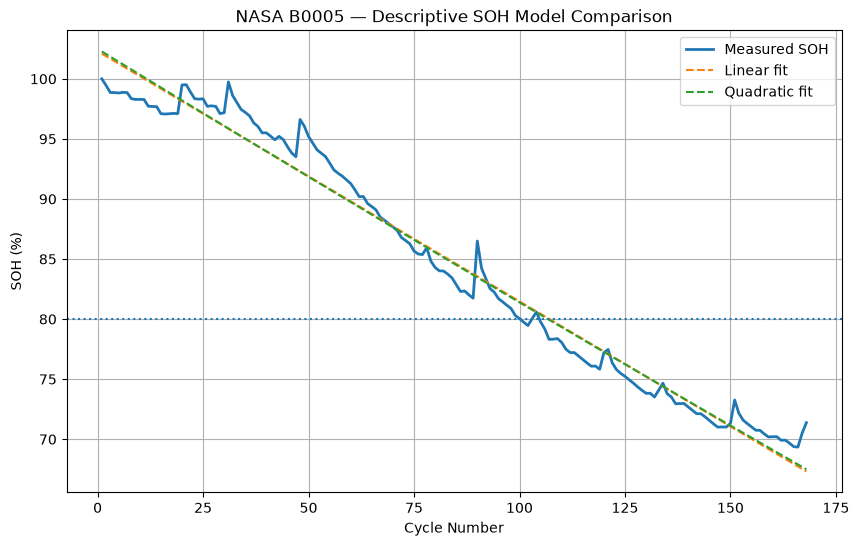

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(df_b0005["cycle"], y_soh, linewidth=2, label="Measured SOH")
plt.plot(df_b0005["cycle"], soh_linear_pred, linestyle="--", label="Linear fit")
plt.plot(df_b0005["cycle"], soh_quad_pred, linestyle="--", label="Quadratic fit")
plt.axhline(80, linestyle=":")
plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.title("NASA B0005 — Descriptive SOH Model Comparison")
plt.legend()
plt.grid(True)
plt.show()


## 5. EOL definition and RUL target

EOL is defined as the **first measured discharge cycle at or below 80% SOH**.

For an observation at cycle \(t\):

\[
RUL_t = \max(EOL_{cycle} - t,\ 0)
\]

This creates a deterministic target once the observed EOL is known. Therefore, a model using `cycle` as an input can reproduce this target almost perfectly by construction. Such a cycle-only result is a **sanity check, not a deployable prognostic model**.


In [11]:
EOL_SOH = 80.0

eol_candidates = df_b0005.loc[
    df_b0005["SOH_percent"] <= EOL_SOH,
    ["cycle", "SOH_percent"],
]

if eol_candidates.empty:
    raise ValueError("B0005 does not reach the selected 80% SOH EOL threshold.")

eol_cycle = float(eol_candidates.iloc[0]["cycle"])
eol_soh = float(eol_candidates.iloc[0]["SOH_percent"])

df_b0005["RUL_cycles"] = (eol_cycle - df_b0005["cycle"]).clip(lower=0)

print(f"EOL threshold: {EOL_SOH:.1f}% SOH")
print(f"Observed EOL cycle: {eol_cycle:.0f}")
print(f"SOH at first EOL observation: {eol_soh:.2f}%")


EOL threshold: 80.0% SOH
Observed EOL cycle: 101
SOH at first EOL observation: 79.74%


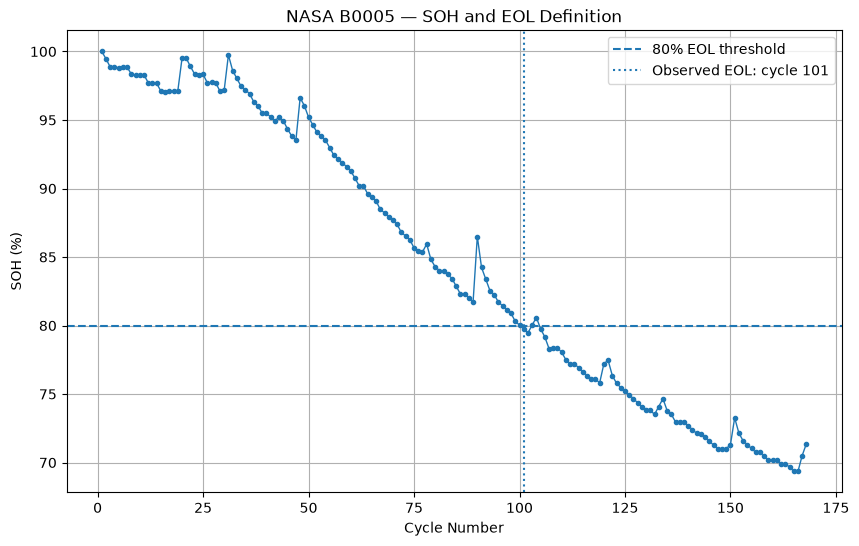

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(df_b0005["cycle"], df_b0005["SOH_percent"], marker="o", markersize=3, linewidth=1)
plt.axhline(EOL_SOH, linestyle="--", label=f"{EOL_SOH:.0f}% EOL threshold")
plt.axvline(eol_cycle, linestyle=":", label=f"Observed EOL: cycle {eol_cycle:.0f}")
plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.title("NASA B0005 — SOH and EOL Definition")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
rul_df = (
    df_b0005.loc[df_b0005["cycle"] < eol_cycle]
    .copy()
    .reset_index(drop=True)
)

print("Pre-EOL observations:", len(rul_df))
print(
    f"Cycle range: {rul_df['cycle'].min():.0f} "
    f"to {rul_df['cycle'].max():.0f}"
)
print(
    f"RUL range: {rul_df['RUL_cycles'].min():.0f} "
    f"to {rul_df['RUL_cycles'].max():.0f} cycles"
)


Pre-EOL observations: 100
Cycle range: 1 to 100
RUL range: 1 to 100 cycles


## 6. Chronological RUL validation

A 70/30 chronological split is used. Earlier-life observations form the training set and later-life observations form the test set. No shuffling is used.


In [14]:
split_index = int(len(rul_df) * 0.70)

train_rul = rul_df.iloc[:split_index].copy()
test_rul = rul_df.iloc[split_index:].copy()

assert train_rul["cycle"].max() < test_rul["cycle"].min()

print("Training observations:", len(train_rul))
print("Testing observations:", len(test_rul))
print(
    f"Train cycle range: {train_rul['cycle'].min():.0f} "
    f"to {train_rul['cycle'].max():.0f}"
)
print(
    f"Test cycle range: {test_rul['cycle'].min():.0f} "
    f"to {test_rul['cycle'].max():.0f}"
)


Training observations: 70
Testing observations: 30
Train cycle range: 1 to 70
Test cycle range: 71 to 100


### 6.1 Cycle-only identity baseline

This baseline is retained only to demonstrate the target construction. Because `RUL = EOL − cycle`, its near-perfect performance is mathematically expected and must **not** be presented as an ML forecasting achievement.


In [15]:
cycle_baseline = LinearRegression()
cycle_baseline.fit(train_rul[["cycle"]], train_rul["RUL_cycles"])
cycle_baseline_pred = cycle_baseline.predict(test_rul[["cycle"]])

cycle_baseline_metrics = {
    "Model": "Cycle-only identity baseline",
    "MAE_cycles": mean_absolute_error(test_rul["RUL_cycles"], cycle_baseline_pred),
    "RMSE_cycles": np.sqrt(mean_squared_error(test_rul["RUL_cycles"], cycle_baseline_pred)),
    "R2": r2_score(test_rul["RUL_cycles"], cycle_baseline_pred),
    "Bias_cycles": np.mean(cycle_baseline_pred - test_rul["RUL_cycles"]),
}

cycle_baseline_metrics


{'Model': 'Cycle-only identity baseline',
 'MAE_cycles': 1.9421501444109406e-14,
 'RMSE_cycles': np.float64(2.0593484956335486e-14),
 'R2': 1.0,
 'Bias_cycles': np.float64(1.9421501444109406e-14)}

### 6.2 Health-based models

For predictive evaluation, `cycle` is excluded from the feature set. This prevents the model from trivially reconstructing the RUL target from cycle number.

Note that `SOH_percent` and `capacity_Ah` are strongly related by definition. Both are retained here for comparison with the existing project workflow, but their redundancy should be considered during future feature selection.


In [16]:
health_features = [
    "SOH_percent",
    "capacity_Ah",
    "avg_voltage_V",
    "min_voltage_V",
    "max_voltage_V",
    "avg_current_A",
    "avg_temperature_C",
    "max_temperature_C",
]

missing_health_features = [c for c in health_features if c not in rul_df.columns]
if missing_health_features:
    raise ValueError(f"Missing health features: {missing_health_features}")

X_train_health = train_rul[health_features].copy()
X_test_health = test_rul[health_features].copy()
y_train_rul = train_rul["RUL_cycles"].copy()
y_test_rul = test_rul["RUL_cycles"].copy()

assert len(X_train_health) == len(y_train_rul)
assert len(X_test_health) == len(y_test_rul)

print("X_train:", X_train_health.shape)
print("X_test:", X_test_health.shape)
print("y_train:", y_train_rul.shape)
print("y_test:", y_test_rul.shape)


X_train: (70, 8)
X_test: (30, 8)
y_train: (70,)
y_test: (30,)


In [17]:
def regression_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE_cycles": mean_absolute_error(y_true, y_pred),
        "RMSE_cycles": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Bias_cycles": np.mean(np.asarray(y_pred) - np.asarray(y_true)),
    }

health_linear_model = LinearRegression()
health_linear_model.fit(X_train_health, y_train_rul)
health_linear_pred = health_linear_model.predict(X_test_health)

rf_rul_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=8,
    min_samples_leaf=2,
    n_jobs=-1,
)
rf_rul_model.fit(X_train_health, y_train_rul)
rf_rul_pred = rf_rul_model.predict(X_test_health)

rul_model_summary = pd.DataFrame([
    cycle_baseline_metrics,
    regression_metrics(
        "Health-based Linear Regression",
        y_test_rul,
        health_linear_pred,
    ),
    regression_metrics(
        "Health-based Random Forest",
        y_test_rul,
        rf_rul_pred,
    ),
])

rul_model_summary


,Model,MAE_cycles,RMSE_cycles,R2,Bias_cycles
0,Cycle-only identity baseline,1.942150e-14,2.059348e-14,1.000000,1.942150e-14
1,Health-based Linear Regression,5.461630e+00,7.239710e+00,0.300377,5.396141e+00
2,Health-based Random Forest,1.729022e+01,1.932445e+01,-3.984663,1.729022e+01


### 6.3 Feature importance and residual diagnostics

Random-forest importance is descriptive; correlated predictors can split or distort importance. It should not be interpreted as a causal ranking.


In [18]:
rf_feature_importance = (
    pd.DataFrame({
        "feature": health_features,
        "importance": rf_rul_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

rf_feature_importance


,feature,importance
0,capacity_Ah,0.377785
1,SOH_percent,0.371613
2,avg_current_A,0.077065
3,max_voltage_V,0.074341
4,max_temperature_C,0.042193
5,avg_voltage_V,0.030379
6,avg_temperature_C,0.025175
7,min_voltage_V,0.001449


In [19]:
test_results = test_rul[["cycle", "SOH_percent", "RUL_cycles"]].copy()
test_results["RUL_pred_linear"] = np.clip(health_linear_pred, 0, None)
test_results["RUL_pred_rf"] = np.clip(rf_rul_pred, 0, None)
test_results["RF_error"] = test_results["RUL_pred_rf"] - test_results["RUL_cycles"]

test_results.head()


,cycle,SOH_percent,RUL_cycles,RUL_pred_linear,RUL_pred_rf,RF_error
70,71,87.376056,30.0,29.017667,32.756510,2.756510
71,72,86.794321,29.0,30.470877,32.764710,3.764710
72,73,86.537788,28.0,28.539971,32.726148,4.726148
73,74,86.265827,27.0,27.150933,32.750415,5.750415
74,75,85.665500,26.0,26.713328,32.749677,6.749677


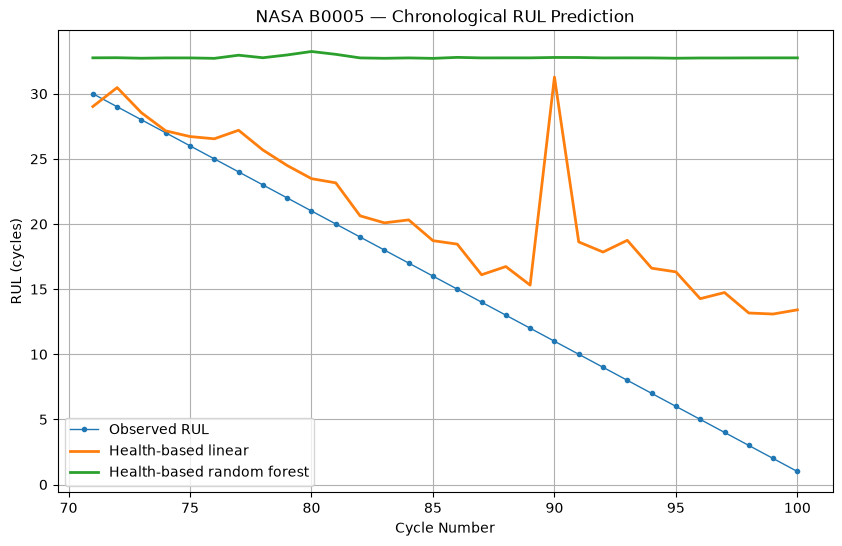

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(
    test_results["cycle"],
    test_results["RUL_cycles"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="Observed RUL",
)
plt.plot(
    test_results["cycle"],
    test_results["RUL_pred_linear"],
    linewidth=2,
    label="Health-based linear",
)
plt.plot(
    test_results["cycle"],
    test_results["RUL_pred_rf"],
    linewidth=2,
    label="Health-based random forest",
)
plt.xlabel("Cycle Number")
plt.ylabel("RUL (cycles)")
plt.title("NASA B0005 — Chronological RUL Prediction")
plt.legend()
plt.grid(True)
plt.show()


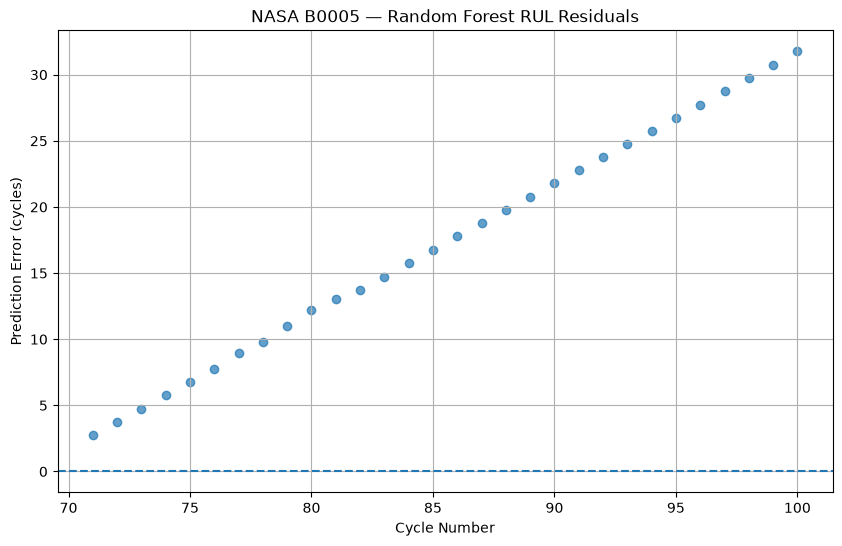

Mean RF RUL error: 17.29 cycles
Median RF RUL error: 17.25 cycles


In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(test_results["cycle"], test_results["RF_error"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Cycle Number")
plt.ylabel("Prediction Error (cycles)")
plt.title("NASA B0005 — Random Forest RUL Residuals")
plt.grid(True)
plt.show()

print(f"Mean RF RUL error: {test_results['RF_error'].mean():.2f} cycles")
print(f"Median RF RUL error: {test_results['RF_error'].median():.2f} cycles")


### NOTE
The Random Forest exhibits systematic positive RUL bias under chronological extrapolation. Its inability to extrapolate beyond health states represented in the training period causes increasingly optimistic RUL predictions during late-life degradation.

In [22]:
linear_errors = (
    test_results["RUL_pred_linear"]
    - test_results["RUL_cycles"]
)

print(f"Mean Linear RUL error: {linear_errors.mean():.2f} cycles")
print(f"Median Linear RUL error: {linear_errors.median():.2f} cycles")
print(f"Min Linear RUL error: {linear_errors.min():.2f} cycles")
print(f"Max Linear RUL error: {linear_errors.max():.2f} cycles")

Mean Linear RUL error: 5.40 cycles
Median Linear RUL error: 3.25 cycles
Min Linear RUL error: -0.98 cycles
Max Linear RUL error: 20.28 cycles


In [23]:
test_results[
    [
        "cycle",
        "SOH_percent",
        "RUL_cycles",
        "RUL_pred_linear",
        "RUL_pred_rf",
    ]
].tail(10)

,cycle,SOH_percent,RUL_cycles,RUL_pred_linear,RUL_pred_rf
90,91,84.236991,10.0,18.622710,32.781277
91,92,83.388204,9.0,17.846731,32.750415
92,93,82.541662,8.0,18.747811,32.753715
93,94,82.249565,7.0,16.608608,32.750415
94,95,81.711154,6.0,16.324588,32.726148
95,96,81.438612,5.0,14.266144,32.744415
96,97,81.151312,4.0,14.737830,32.744415
97,98,80.880987,3.0,13.167926,32.750415
98,99,80.304579,2.0,13.088205,32.753715
99,100,80.036545,1.0,13.410265,32.753715


In [24]:
test_results = test_results.copy()

test_results["linear_error"] = (
    test_results["RUL_pred_linear"]
    - test_results["RUL_cycles"]
)

test_results[
    [
        "cycle",
        "SOH_percent",
        "RUL_cycles",
        "RUL_pred_linear",
        "linear_error",
    ]
].tail(10)

,cycle,SOH_percent,RUL_cycles,RUL_pred_linear,linear_error
90,91,84.236991,10.0,18.622710,8.622710
91,92,83.388204,9.0,17.846731,8.846731
92,93,82.541662,8.0,18.747811,10.747811
93,94,82.249565,7.0,16.608608,9.608608
94,95,81.711154,6.0,16.324588,10.324588
95,96,81.438612,5.0,14.266144,9.266144
96,97,81.151312,4.0,14.737830,10.737830
97,98,80.880987,3.0,13.167926,10.167926
98,99,80.304579,2.0,13.088205,11.088205
99,100,80.036545,1.0,13.410265,12.410265


In [25]:
test_results[
    [
        "cycle",
        "SOH_percent",
        "RUL_cycles",
        "RUL_pred_linear",
        "linear_error",
    ]
].sort_values(
    "linear_error",
    ascending=False
).head(10)

,cycle,SOH_percent,RUL_cycles,RUL_pred_linear,linear_error
89,90,86.497699,11.0,31.277301,20.277301
99,100,80.036545,1.0,13.410265,12.410265
98,99,80.304579,2.0,13.088205,11.088205
92,93,82.541662,8.0,18.747811,10.747811
96,97,81.151312,4.0,14.737830,10.737830
94,95,81.711154,6.0,16.324588,10.324588
97,98,80.880987,3.0,13.167926,10.167926
93,94,82.249565,7.0,16.608608,9.608608
95,96,81.438612,5.0,14.266144,9.266144
91,92,83.388204,9.0,17.846731,8.846731


## 7. Model-implied EOL diagnostic

Each RUL prediction implies an EOL estimate:

\[
\widehat{EOL}_t = cycle_t + \widehat{RUL}_t
\]

A stable prognostic model should produce EOL estimates that converge as the battery approaches failure. The median implied EOL over the chronological test period is reported as a diagnostic—not as an independently validated EOL forecast.


In [26]:
test_results["EOL_implied_rf"] = (
    test_results["cycle"] + test_results["RUL_pred_rf"]
)

rf_implied_eol = test_results["EOL_implied_rf"].median()
rf_eol_error = rf_implied_eol - eol_cycle

print(f"Observed EOL: {eol_cycle:.0f} cycles")
print(f"Median RF-implied EOL: {rf_implied_eol:.2f} cycles")
print(f"RF-implied EOL error: {rf_eol_error:.2f} cycles")


Observed EOL: 101 cycles
Median RF-implied EOL: 118.25 cycles
RF-implied EOL error: 17.25 cycles


In [27]:
# Model-implied EOL from Linear Regression

test_results = test_results.copy()

test_results["EOL_implied_linear"] = (
    test_results["cycle"]
    + test_results["RUL_pred_linear"]
)

median_linear_eol = test_results["EOL_implied_linear"].median()

# Recover observed EOL from the RUL definition
observed_eol = int(
    rul_df["cycle"].iloc[0]
    + rul_df["RUL_cycles"].iloc[0]
)

print(f"Observed EOL: {observed_eol} cycles")
print(
    f"Median Linear-implied EOL: "
    f"{median_linear_eol:.2f} cycles"
)
print(
    f"Linear-implied EOL error: "
    f"{median_linear_eol - observed_eol:.2f} cycles"
)

Observed EOL: 101 cycles
Median Linear-implied EOL: 104.25 cycles
Linear-implied EOL error: 3.25 cycles


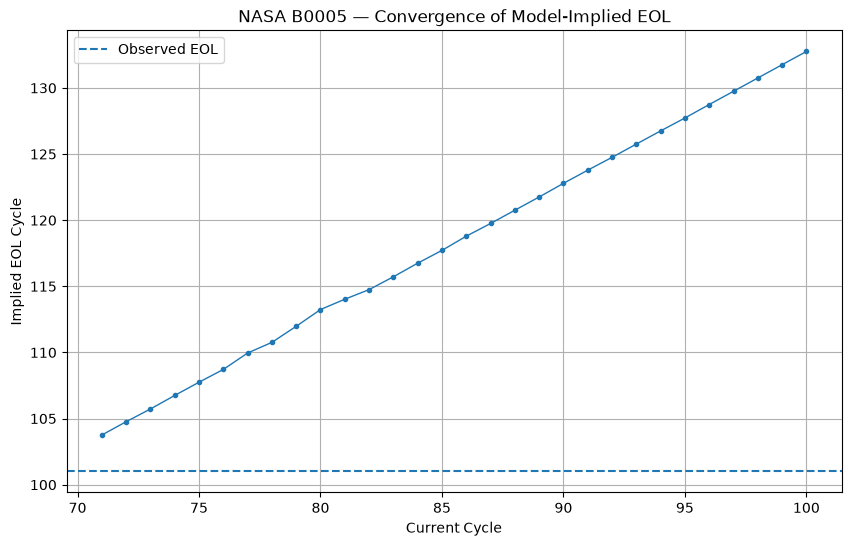

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(
    test_results["cycle"],
    test_results["EOL_implied_rf"],
    marker="o",
    markersize=3,
    linewidth=1,
)
plt.axhline(eol_cycle, linestyle="--", label="Observed EOL")
plt.xlabel("Current Cycle")
plt.ylabel("Implied EOL Cycle")
plt.title("NASA B0005 — Convergence of Model-Implied EOL")
plt.legend()
plt.grid(True)
plt.show()


## 8. Chronological SOH extrapolation check

A high in-sample SOH fit does not guarantee reliable future forecasting. The following experiment trains only on the first 70% of observations and evaluates SOH on later cycles.


In [29]:
soh_split = int(len(df_b0005) * 0.70)

soh_train = df_b0005.iloc[:soh_split].copy()
soh_test = df_b0005.iloc[soh_split:].copy()

soh_chrono_model = LinearRegression()
soh_chrono_model.fit(soh_train[["cycle"]], soh_train["SOH_percent"])

soh_chrono_pred = soh_chrono_model.predict(soh_test[["cycle"]])

soh_chrono_metrics = {
    "MAE_SOH_pct": mean_absolute_error(soh_test["SOH_percent"], soh_chrono_pred),
    "RMSE_SOH_pct": np.sqrt(
        mean_squared_error(soh_test["SOH_percent"], soh_chrono_pred)
    ),
    "R2": r2_score(soh_test["SOH_percent"], soh_chrono_pred),
    "Bias_SOH_pct": np.mean(soh_chrono_pred - soh_test["SOH_percent"]),
}

soh_chrono_metrics


{'MAE_SOH_pct': 1.215529007987099,
 'RMSE_SOH_pct': np.float64(1.6612001759528787),
 'R2': 0.3944146492774867,
 'Bias_SOH_pct': np.float64(-0.9375329337399619)}

## 9. Cross-battery sanity check

B0006 is loaded only as an exploratory comparison. A stronger final project should train on multiple batteries and evaluate on a **held-out battery** (for example, train on B0005/B0006/B0007 and test on B0018, subject to consistent preprocessing and EOL availability).


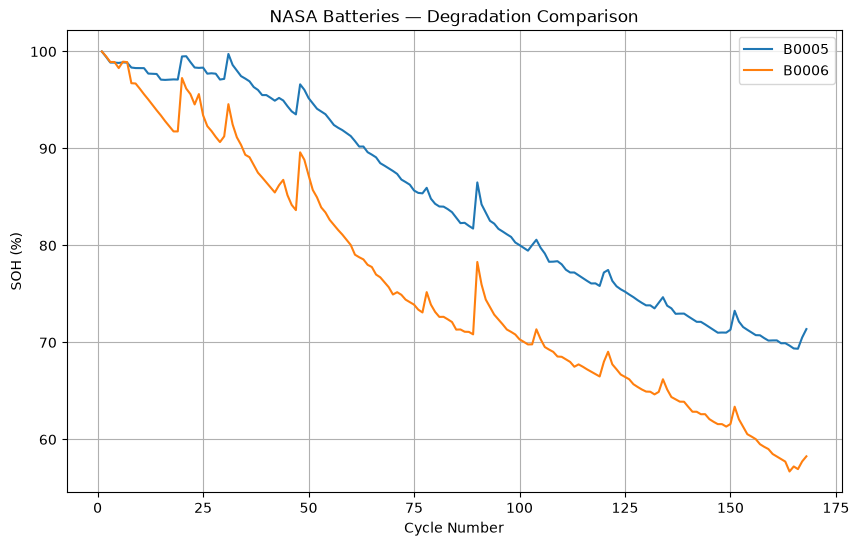

In [30]:
if b0006_path.exists():
    df_b0006 = load_nasa_battery(b0006_path, "B0006")
    df_b0006 = add_soh_features(df_b0006)

    plt.figure(figsize=(10, 6))
    plt.plot(df_b0005["cycle"], df_b0005["SOH_percent"], label="B0005")
    plt.plot(df_b0006["cycle"], df_b0006["SOH_percent"], label="B0006")
    plt.xlabel("Cycle Number")
    plt.ylabel("SOH (%)")
    plt.title("NASA Batteries — Degradation Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("B0006.mat not found; cross-battery comparison skipped.")


In [31]:
# Validate B0006 after corrected discharge-cycle indexing

print(f"B0006 shape: {df_b0006.shape}")

print(
    f"First discharge cycle: "
    f"{int(df_b0006['cycle'].iloc[0])}"
)

print(
    f"Last discharge cycle: "
    f"{int(df_b0006['cycle'].iloc[-1])}"
)

print(
    f"Initial capacity: "
    f"{df_b0006['capacity_Ah'].iloc[0]:.4f} Ah"
)

print(
    f"Final capacity: "
    f"{df_b0006['capacity_Ah'].iloc[-1]:.4f} Ah"
)

print(
    f"Initial SOH: "
    f"{df_b0006['SOH_percent'].iloc[0]:.2f}%"
)

print(
    f"Final SOH: "
    f"{df_b0006['SOH_percent'].iloc[-1]:.2f}%"
)

# Verify corrected indexing
assert (
    df_b0006["cycle"].to_numpy()
    == df_b0006["discharge_cycle"].to_numpy()
).all()

assert (
    df_b0006["discharge_cycle"].to_numpy()
    == range(1, len(df_b0006) + 1)
).all()

print("B0006 discharge-cycle indexing: PASS")

B0006 shape: (168, 14)
First discharge cycle: 1
Last discharge cycle: 168
Initial capacity: 2.0353 Ah
Final capacity: 1.1857 Ah
Initial SOH: 100.00%
Final SOH: 58.25%
B0006 discharge-cycle indexing: PASS


## 10. Conclusions and next modelling stage

This notebook separates **descriptive degradation fitting** from **predictive prognostics**.

Key methodological points:

- EOL is defined consistently as the first measured cycle at or below 80% SOH.
- Only one authoritative RUL target, `RUL_cycles`, is maintained.
- Chronological splitting is used for predictive evaluation.
- The cycle-only RUL model is explicitly treated as a target-identity sanity check, not a forecasting result.
- Health-based models exclude cycle number to avoid trivial reconstruction of `RUL = EOL − cycle`.
- MAE, RMSE, R² and signed bias are reported together.
- Model-implied EOL is evaluated as an additional stability diagnostic.
- In-sample SOH fit is not treated as evidence of long-horizon prognostic ability.

**Next recommended stage:** move from single-battery modelling to cross-battery validation, engineer only features observable at inference time, and evaluate uncertainty/conformal intervals for RUL predictions.


In [32]:
record_index       # original NASA event index
discharge_cycle    # 1, 2, 3, ... for discharge observations only

NameError: name 'record_index' is not defined